#PROYECTO INTEGRADOR GRUPO 6
#Modelo Predictivo para la Identificación de Pólizas no Renovadas Aplicado al Sector Asegurador

Integrantes:

*   Juan Carlos Fonseca Florez
*   Zarith Dorelly Gómez Vargas
*   Erika Fernanda Jiménez camargo



#ANÁLISIS EXPLORATORIO EDA Y PREPROCESAMIENTO

#1.ANÁLISIS EXPLORATORIO EDA

In [ ]:
#Importación de Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Carga de Datos
#Lectura de archivo de siniestros
try:
    siniestros = pd.read_csv('siniestros_2025_tokenizado1.csv')
    print("Datos cargados exitosamente:")
    print(siniestros.info())
except FileNotFoundError:
    print("Error: El archivo 'siniestros_2025_tokenizado1.csv' no fue encontrado. Por favor, verifica la ruta y el nombre del archivo.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados exitosamente:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9178 entries, 0 to 9177
Columns: 135 entries, Rut_Contratante to Observacion
dtypes: float64(43), object(92)
memory usage: 9.5+ MB
None


/tmp/ipykernel_15734/3990847405.py:4: DtypeWarning: Columns (76,77,78,79,80,101,102,123,128) have mixed types. Specify dtype option on import or set low_memory=False.
  siniestros = pd.read_csv('siniestros_2025_tokenizado1.csv')


In [ ]:
# Datos de producción
try:
    produccion = pd.read_parquet('libro de producción_tokenizado2.parquet')
    print("Datos cargados exitosamente:")
    print(produccion.info())
except FileNotFoundError:
    print("Error: El archivo 'libro de producción_tokenizado2.parquet' no fue encontrado. Por favor, verifica la ruta y el nombre del archivo.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

Datos cargados exitosamente:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192117 entries, 0 to 192116
Columns: 143 entries, Num_Propuesta to Es_Profundizacion
dtypes: float64(36), int64(1), object(106)
memory usage: 209.6+ MB
None


##1.1 Validación Inicial

In [ ]:
#Número de Filas y Columas

print('Dataset Producción:', produccion.shape)
print('Dataset Siniestros:', siniestros.shape)

Dataset Producción: (192117, 143)
Dataset Siniestros: (9178, 135)


In [ ]:
#Tipos de Datos
print(produccion.dtypes)
print(siniestros.dtypes)

Num_Propuesta                              int64
Num_Poliza                                object
Num_Poliza_Cobranza                       object
Tipo_Propuesta                            object
Fecha_Creacion                            object
                                          ...   
Ejec_Servicio                             object
Fecha_Despacho                            object
Utimo_Email_Principal_Despacho_Poliza     object
Corredora                                 object
Es_Profundizacion                        float64
Length: 143, dtype: object
Rut_Contratante                object
Razon_Social_Contratante       object
Direccion_Contrat              object
Comuna_Contrat                 object
Ciudad_Contrat                 object
                               ...   
Cobertura_Afectada            float64
Texto_Deducible               float64
Fecha_Carga_Inf_Inspeccion    float64
Riesgo_Comercial               object
Observacion                    object
Length: 135, dty

In [ ]:
#Primeras Filas

print(produccion.head())
print(siniestros.head())

   Num_Propuesta Num_Poliza Num_Poliza_Cobranza Tipo_Propuesta  \
0         858107     528346                None         Póliza   
1         858766      68840                None         Póliza   
2         860688    7662072                None         Póliza   
3         860692    7662073                None         Póliza   
4         860728   61920499                None         Póliza   

        Fecha_Creacion  Dias_Creado Nombre_Estado       Contratante  \
0  2025-01-01 00:00:00        488.0        Póliza  342cf1079122e6d8   
1  2025-01-17 00:00:00        472.0        Póliza  6581e24fe1ac675f   
2  2025-01-01 00:00:00        488.0        Póliza  54c0fdd0a121d906   
3  2025-01-31 00:00:00        458.0        Póliza  baf086514dd59411   
4  2025-01-08 00:00:00        481.0        Póliza  d4fad8852cbadcd0   

  Email_Contratante         Asegurado  ... Porc_Facultativo  \
0  04eddbb3542259e3  342cf1079122e6d8  ...              0.0   
1  8a1ffb12790bb742  6581e24fe1ac675f  ...        

##1.2 Calidad de Datos

In [ ]:
#Valores Duplicados
print('Duplicados Producción:', produccion.duplicated().sum())
print('Duplicados Siniestros:', siniestros.duplicated().sum())

Duplicados Producción: 0
Duplicados Siniestros: 5


In [ ]:
#Valores Nulos
nulos_prod = produccion.isnull().sum().sort_values(ascending=False)
nulos_sin = siniestros.isnull().sum().sort_values(ascending=False)

print(nulos_prod)
print(nulos_sin)

porcentaje_nulos_prod = (produccion.isnull().sum() / len(produccion)) * 100
porcentaje_nulos_sin = (siniestros.isnull().sum() / len(siniestros)) * 100

porcentaje_nulos_prod = porcentaje_nulos_prod.sort_values(ascending=False)
porcentaje_nulos_sin = porcentaje_nulos_sin.sort_values(ascending=False)

print(porcentaje_nulos_prod)
print(porcentaje_nulos_sin)

Usr_Inf_Corte              192117
Ini_Usr_Informa_Corte      192117
IniVendedor                192117
Tipo_Salida_Certificado    192117
Es_Profundizacion          192117
                            ...  
Contratante                     7
Nombre_Estado                   7
Tipo_Propuesta                  7
Fecha_Creacion                  7
Num_Propuesta                   0
Length: 143, dtype: int64
Zona_Comision               9178
Num_Factura                 9178
Monto_Facturar_Final        9178
Fecha_Cobranza              9178
Fecha_Pagado                9178
                            ... 
Compania                      12
Num_Poliza                    12
Correlativo                   12
Razon_Social_Contratante       7
Rut_Contratante                0
Length: 135, dtype: int64
Usr_Inf_Corte              100.000000
Ini_Usr_Informa_Corte      100.000000
IniVendedor                100.000000
Tipo_Salida_Certificado    100.000000
Es_Profundizacion          100.000000
                     

##1.3 Estadísticas Descriptivas

In [ ]:
#Variables Numéricas
print(produccion.describe())

       Num_Propuesta    Dias_Creado  Total_Prima_Bruta_Moneda  \
count   1.921170e+05  192110.000000              1.898880e+05   
mean    1.011895e+06     174.686518              4.219053e+03   
std     7.447505e+04     128.185179              1.046387e+06   
min     8.581070e+05       0.000000             -8.735108e+06   
25%     9.622060e+05      73.000000              9.639000e-01   
50%     1.018029e+06     160.000000              1.149540e+01   
75%     1.071361e+06     258.000000              2.856000e+01   
max     1.177974e+06     488.000000              3.716526e+08   

       Total_Prima_Bruta_Peso        Cambio  Paga_Num_Cuotas  \
count            1.882710e+05  1.903740e+05    191991.000000   
mean             1.911792e+06  3.234299e+04         3.513383   
std              2.352886e+08  5.838288e+04         7.085077   
min             -1.858644e+10  0.000000e+00         0.000000   
25%              0.000000e+00  3.841669e+04         1.000000   
50%              3.226930e+05 

In [ ]:
#Variables Categóricas
print(produccion.describe(include='object'))

       Num_Poliza Num_Poliza_Cobranza Tipo_Propuesta       Fecha_Creacion  \
count      190519                 100         192110               192110   
unique     146437                  96              2                  481   
top     300502984               53578         Póliza  2026-03-30 00:00:00   
freq          176                   2         144007                20144   

       Nombre_Estado       Contratante Email_Contratante         Asegurado  \
count         192110            192110            152388            185156   
unique             7             35395             15132             44030   
top           Póliza  30cf20355a75e0ef  3cbff1e69f4f2f01  30cf20355a75e0ef   
freq          162943             64509             65536             26229   

         Email_Asegurado      Beneficiario  ...      Categorias Facultativo  \
count             136626            182437  ...             116      191604   
unique             14352             24107  ...               1  

#2.PREPROCESAMIENTO O LIMPIEZA


##2.1 Eliminación de columnas cifradas y filas duplicadas

In [ ]:
# Se eliminan columnas con datos cifrados (Alfanuméricos) del dataset producción
produccion = produccion.drop(columns=['Contratante',
 'Email_Contratante',
 'Asegurado',
 'Email_Asegurado',
 'Beneficiario',
 'Nombre_Pagador',
 'Apellido_Pagador',
 'Razon_Social_Pagador',
 'Telefono_Pagador',
 'Celular_Pagador',
 'Email_Pagador',
 'Rut_Pagador',
 'Rut_Contratante',
 'Rut_Asegurado',
 'Email_Cliente'])

produccion.drop_duplicates(inplace=True)

In [ ]:
#Resumen de como quedo el dataset Producción
produccion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192117 entries, 0 to 192116
Columns: 128 entries, Num_Propuesta to Es_Profundizacion
dtypes: float64(36), int64(1), object(91)
memory usage: 187.6+ MB


In [ ]:
# Se eliminan columnas con datos cifrados (Alfanuméricos) del dataset de siniestros
siniestros = siniestros.drop(columns=['Rut_Contratante',
'Rut_Denunciante',
 'Razon_Social_Contratante',
 'Telefono_Contrat',
 'Fecha_Nacimiento',
 'Celular_Contrat',
 'Email_Contrat',
 'Rut_Asegurado',
 'Rut_Otro_Asegurado',
 'Otro_Asegurado',
 'Razon_Social_Asegurado',
 'Email_Asegurado',
 'Razon_Social_Beneficiario',
 'Nombre_Denunciante',
 'Apellido_Denunciante',
 'Telefono_Denunciante',
 'Celular_Denunciante',
 ])
siniestros.drop_duplicates(inplace=True)

In [ ]:
# Resumen de como quedo el dataset Siniestros
siniestros.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9173 entries, 0 to 9177
Columns: 118 entries, Direccion_Contrat to Observacion
dtypes: float64(43), object(75)
memory usage: 8.3+ MB


##2.2 Union de las dos tablas

Se unen por medio del campo `Num_Poliza`, además se crean dos tablas nuevas, los datos que serán usados en el dashboard y los otros que se utilizarán en el modelo.

In [ ]:
datos = pd.merge(siniestros, produccion, on='Num_Poliza', how="left")

In [ ]:
datosDashboard = pd.merge(produccion, siniestros, on='Num_Poliza', how="left")

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122474 entries, 0 to 122473
Columns: 245 entries, Direccion_Contrat to Es_Profundizacion
dtypes: float64(80), object(165)
memory usage: 228.9+ MB


##2.3 Eliminación de columnas basado en el conocimiento de negocio

In [ ]:
columnas1=["Direccion_Contrat",
"Comuna_Contrat",
"Ciudad_Contrat",
"Pais_Contrat",
"Correlativo",
"Num_Poliza",
"Num_Item",
"Num_Siniestro",
"Fecha_Siniestro",
"Materia_x",
"Fecha_Creado",
"Estado",
"Color",
"Ult_Accion",
"Ultima_Accion",
"Subestado",
"Responsable_x",
"Causa",
"Inicio_Vigencia_x",
"Fin_Vigencia_x",
"Nombre_Moneda_x",
"Preventivo",
"Relato_Denuncio",
"Producto_x",
"Asegurado_Indemnizo_Tercero"    ,
"Num_Propuesta"   ,
"Tipo_Propuesta"  ,
"Fecha_Creacion" ,
"Dias_Creado",
"Nombre_Estado",
"Nombre_Compania",
"Rut_Cia",
"Materia_y",
"Grupo",
"Producto_y",
"Ramo",
"Direccion_Contratante",
"Comuna_y",
"Inicio_Vigencia_y",
"Fin_Vigencia_y",
"Responsable_y",
"Iniciales",
"Email_Responsable",
"Ejec_Comercial",
"Es_Endoso",
"Cambio",
"Paga_Num_Cuotas",
"Rut_Beneficiario",
"Porc_Comision",
"Monto_Comision",
"Fecha_Emision_Poliza",
"Fecha_Recepcion_Poliza",
"Fecha_Genera_Poliza",
"Es_Renovacion",
"Nombre_Moneda_y",
"Coaseguro",
"Marcada_No_Renueva",
"Fecha_Propuesta_Enviada_Inicial",
"Fecha_Propuesta_Enviada",
"Sem_Renovacion",
"Año_Renovacion",
"Documento_Poliza",
"Cambio_Actual",
"Sigla",
"Poliza_Con_Problemas",
"Vigente",
"Poliza_Flotante",
"Innominada",
"Tasa_Todo_Riesgo",
"Tasa_Riesgo_Restringido",
"Cant_Planes_Vigentes",
"Prima_Neta_UF",
"Nombre_Sucursal",
"Factura_Anticipada",
"Creador",
"Fecha_Recepcion_Poliza_Inicial",
"Observada",
"Ingresado_Masivamente",
"Veces_Reaperturado",
"Facultativo",
"Porc_Facultativo",
"Falcultativo_Relacionado",
"Corredora",  "Estado_Vigencia","Moneda_Liquidacion",
"Fecha_Endoso", "Num_Endoso",
"Nombre_Tipo_Endoso" 	]

datos = datos.drop(columns=columnas1)
datosDashboard = datosDashboard.drop(columns=columnas1)

##2.4  Eliminación de Columnas nulas

In [ ]:
# Se eliminan columnas que se encuentran sin ningún valor
datosDashboard = datosDashboard.dropna(axis=1, how="all")
datosDashboard = datosDashboard.drop_duplicates()
datos = datos.dropna(axis=1, how="all")
datos = datos.drop_duplicates()

##2.5  Eliminación de Columnas con gran cantidad de nulos

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
datos.isnull().sum().sort_values(ascending = False)

,0
Parrafo,110594
Num_Poliza_Cobranza,110594
Categorias,110593
Ejec_Servicio,110593
Gte_Linea_Negocio,110590
Motivo_Problema,110580
Fecha_Recepcion_Finiquito,110570
Fecha_Finiquito,110570
Categoria,110553
Num_Denuncio_Cia,110551


Se eliminan datos con mas de 50.000 datos nulos

In [ ]:
columnas = [
    "Parrafo", "Num_Poliza_Cobranza", "Categorias", "Ejec_Servicio",
    "Gte_Linea_Negocio", "Fecha_Finiquito", "Fecha_Recepcion_Finiquito",
    "Categoria", "Num_Denuncio_Cia", "Motivo_Problema", "Tipo_Corte_mes_Cobranza",
    "Montivo_No_Renueva", "Fecha_No_Renueva", "Ciudad_x", "Fecha_Caducidad",
    "Fecha_Gar_Suscrip_Terminada", "Fecha_Den_Cia", "Fecha_con_Problema",
    "Fecha_Devuelto_Cia", "Veces_Devuelto_Cia", "Fecha_Rechazo_Cia",
    "Veces_Rechazado_Cia", "Juzgado", "Folio", "Num_Propuesta_Renovada",
    "Fecha_Parte_Policial", "Comisaria", "Monto_Ajuste_Final",
    "Motivo_Rechazo", "Fecha_Ingreso_Masivo", "Comuna_x",
    "Nombre_Poliza", "Riesgo_Asegurado_x", "Fecha_Solic_Documento",
    "Poliza_Asociada", "Fecha_Pago", "Director_Comercial2",
    "Comentario_Ejecutivo", "Fecha_Carga_PDF_Poliza_Endoso",
    "Nombre_Cobertura_Princ_Afectada", "Jefe_Linea_Negocio",
    "Monto_Provision_Inicial", "Monto_Infraseguro_Provision",
    "Monto_Deducible_Provision", "Fecha_Provision", "Utimo_Email_Principal_Despacho_Poliza",
    "Monto_Reclamado", "Recordatorio", "Monto_Asegurado",
    "Fecha_Termino_Liquidacion", "Fecha_Informe_Liquidacion",
    "Conclusion_Pago", "Conclusion_Reparacion",
    "Fecha_Recepcion_Informe", "Num_Propuesta_Cia",
    "Fecha_Primer_Pago", "Monto_Provision", "Observacion",
    "Fecha_Despacho", "Es_Caratula", "Cerrado_A_Tiempo",
    "Tipo_Cierre", "Fecha_Cierre", "Riesgo_Comercial",
    "Monto_Ajustado", "Infraseguro", "Deducible",
    "Monto_Liquidado", "Contacto_Cia", "Fecha_Apertura",
    "Fecha_Enviado", "Cobertura_Principal_Afectada", "Tipo_Perdida",
    "Ejec_Cobranza_y", "Fecha_Asignacion_Cia", "Contrat_Con_Pre_Existencia",
    "Asunto_Ult_Accion", "Monto_Facturar_Moneda",
    "Entrada_Denuncio", "Holding_x", "Ejecutivo_Despachador", "Patente",
    "Holding_y", "Detalle_Endoso", "Fecha_Denuncio"
]


In [ ]:
datos = datos.drop(columns=columnas)

In [ ]:
columnas = [
    "Parrafo", "Num_Poliza_Cobranza", "Categorias", "Ejec_Servicio",
    "Gte_Linea_Negocio", "Fecha_Finiquito", "Fecha_Recepcion_Finiquito",
    "Categoria", "Num_Denuncio_Cia", "Motivo_Problema", "Tipo_Corte_mes_Cobranza",
    "Montivo_No_Renueva", "Fecha_No_Renueva", "Ciudad_x", "Fecha_Caducidad",
    "Fecha_Gar_Suscrip_Terminada", "Fecha_Den_Cia", "Fecha_con_Problema",
    "Fecha_Devuelto_Cia", "Veces_Devuelto_Cia", "Fecha_Rechazo_Cia",
    "Veces_Rechazado_Cia", "Juzgado", "Folio", "Num_Propuesta_Renovada",
    "Fecha_Parte_Policial", "Comisaria", "Monto_Ajuste_Final",
    "Motivo_Rechazo", "Fecha_Ingreso_Masivo", "Comuna_x",
    "Nombre_Poliza", "Riesgo_Asegurado_y", "Fecha_Solic_Documento",
    "Poliza_Asociada", "Fecha_Pago", "Director_Comercial2",
    "Comentario_Ejecutivo", "Fecha_Carga_PDF_Poliza_Endoso",
    "Nombre_Cobertura_Princ_Afectada", "Jefe_Linea_Negocio",
    "Monto_Provision_Inicial", "Monto_Infraseguro_Provision",
    "Monto_Deducible_Provision", "Fecha_Provision", "Utimo_Email_Principal_Despacho_Poliza",
    "Monto_Reclamado", "Recordatorio", "Monto_Asegurado",
    "Fecha_Termino_Liquidacion", "Fecha_Informe_Liquidacion",
    "Conclusion_Pago", "Conclusion_Reparacion",
    "Fecha_Recepcion_Informe", "Num_Propuesta_Cia",
    "Fecha_Primer_Pago", "Monto_Provision", "Observacion",
    "Fecha_Despacho", "Es_Caratula", "Cerrado_A_Tiempo",
    "Tipo_Cierre", "Fecha_Cierre", "Riesgo_Comercial",
    "Monto_Ajustado", "Infraseguro", "Deducible",
    "Monto_Liquidado", "Contacto_Cia", "Fecha_Apertura",
    "Fecha_Enviado", "Cobertura_Principal_Afectada", "Tipo_Perdida",
    "Ejec_Cobranza_x", "Fecha_Asignacion_Cia", "Contrat_Con_Pre_Existencia",
    "Asunto_Ult_Accion", "Monto_Facturar_Moneda",
    "Entrada_Denuncio", "Holding_x", "Ejecutivo_Despachador", "Patente",
    "Holding_y", "Detalle_Endoso", "Fecha_Denuncio"
]


In [ ]:
datosDashboard = datosDashboard.drop(columns=columnas)

###2.5.1 Gráfica para apreciar los nulos

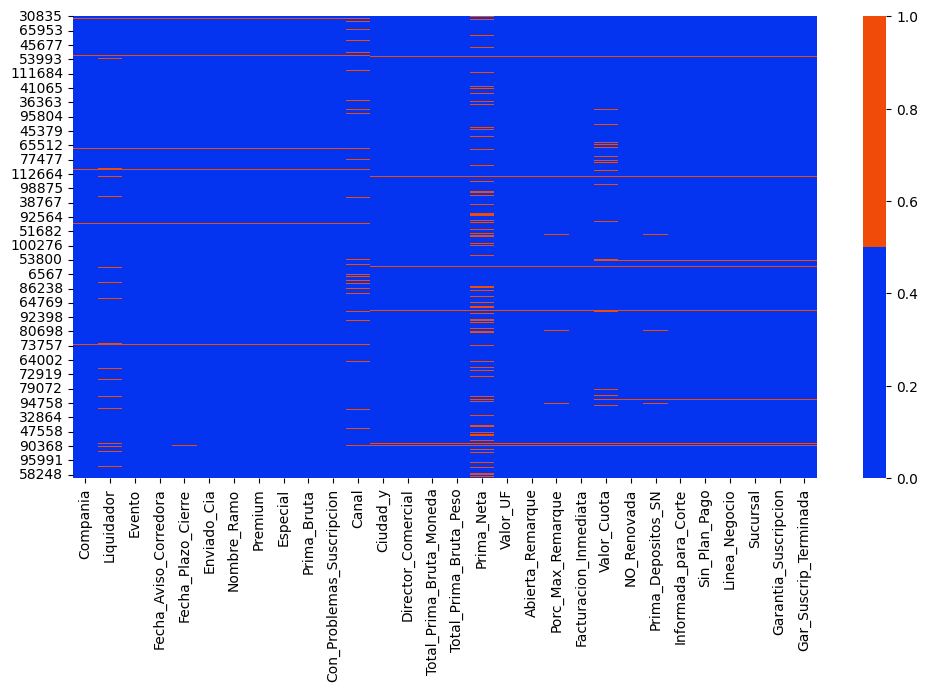

In [ ]:
cols = datos.columns

plt.figure(figsize=(12, 6))

sns.heatmap(
    datos[cols].isnull().sample(1000),  # solo muestra 1000 filas
    cmap=sns.color_palette(['#0534F0', '#F04B08'])
)

plt.show()

In [ ]:
#Valores nulos por columna
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

datos.isnull().sum().sort_values(ascending = False)

,0
Prima_Neta,17370
Liquidador,7716
Canal,7004
Valor_Cuota,6751
Prima_Depositos_SN,3892
Porc_Max_Remarque,3718
Linea_Negocio,2366
Sucursal,2334
Garantia_Suscripcion,2331
Informada_para_Corte,2331


##2.6 Eliminación de columnas con solo un tipo de dato

In [ ]:
datos.nunique().sort_values()

,0
Premium,1
Enviado_Cia,1
Prima_Bruta,1
Especial,1
Con_Problemas_Suscripcion,1
Porc_Max_Remarque,1
Abierta_Remarque,1
Valor_UF,1
Facturacion_Inmediata,1
Gar_Suscrip_Terminada,1


In [ ]:
columnas_un_tipo = [
    "Enviado_Cia",
    "Especial",
    "Premium",
    "Prima_Bruta",
    "Con_Problemas_Suscripcion",
    "Porc_Max_Remarque",
    "Valor_UF",
    "Facturacion_Inmediata",
    "Prima_Depositos_SN",
    "Informada_para_Corte",
    "Gar_Suscrip_Terminada",
    "Abierta_Remarque"]


In [ ]:
datos = datos.drop(columns=columnas_un_tipo)
datosDashboard = datosDashboard.drop(columns=columnas_un_tipo)

In [ ]:
#Cómo van los datos hasta el momento
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110595 entries, 0 to 122473
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Compania                  109157 non-null  object 
 1   Liquidador                102879 non-null  object 
 2   Evento                    109155 non-null  object 
 3   Fecha_Aviso_Corredora     109155 non-null  object 
 4   Fecha_Plazo_Cierre        109091 non-null  object 
 5   Nombre_Ramo               109155 non-null  object 
 6   Canal                     103591 non-null  object 
 7   Ciudad_y                  108445 non-null  object 
 8   Director_Comercial        108441 non-null  object 
 9   Total_Prima_Bruta_Moneda  108407 non-null  float64
 10  Total_Prima_Bruta_Peso    108406 non-null  float64
 11  Prima_Neta                93225 non-null   float64
 12  Valor_Cuota               103844 non-null  float64
 13  NO_Renovada               108265 non-null  object

##2.7 Imputación de valores nulos restantes

In [ ]:
# Rellenar valores nulos para columnas numéricas con la mediana
for col in ['Total_Prima_Bruta_Moneda', 'Total_Prima_Bruta_Peso', 'Prima_Neta', 'Valor_Cuota', 'Dias_Entre_Aviso_Cierre']:
    if col in datos.columns:
        median_val = datos[col].median()
        datos[col]= datos[col].fillna(median_val)
        print(f"Columna '{col}': nulos rellenados con la mediana ({median_val})")

# Rellenar valores nulos para columnas categóricas y datetime con la moda
for col in ['Liquidador', 'Fecha_Plazo_Cierre', 'Fecha_Denuncio', 'Canal', 'Ciudad_y', 'Director_Comercial', 'NO_Renovada', 'Sin_Plan_Pago', 'Linea_Negocio', 'Sucursal', 'Garantia_Suscripcion']:
    if col in datos.columns:
        mode_val = datos[col].mode()[0]
        datos[col] = datos[col].fillna(mode_val)
        print(f"Columna '{col}': nulos rellenados con la moda ({mode_val})")

print("\nInformación del DataFrame después de rellenar nulos:")
datos.info()

Columna 'Total_Prima_Bruta_Moneda': nulos rellenados con la mediana (3.642)
Columna 'Total_Prima_Bruta_Peso': nulos rellenados con la mediana (0.0)
Columna 'Prima_Neta': nulos rellenados con la mediana (8.34)
Columna 'Valor_Cuota': nulos rellenados con la mediana (0.0)
Columna 'Liquidador': nulos rellenados con la moda (Liquidador Interno Compañia)
Columna 'Fecha_Plazo_Cierre': nulos rellenados con la moda (2025-12-25)
Columna 'Canal': nulos rellenados con la moda (DIR)
Columna 'Ciudad_y': nulos rellenados con la moda (Santiago)
Columna 'Director_Comercial': nulos rellenados con la moda (BENNETT GUZMÁN, Carlos Alberto)
Columna 'NO_Renovada': nulos rellenados con la moda (False)
Columna 'Sin_Plan_Pago': nulos rellenados con la moda (False)
Columna 'Linea_Negocio': nulos rellenados con la moda (Flotas)
Columna 'Sucursal': nulos rellenados con la moda (THB Santiago)
Columna 'Garantia_Suscripcion': nulos rellenados con la moda (False)

Información del DataFrame después de rellenar nulos:
<

##2.8 Resultado del Preprocesamiento

In [ ]:
print(datos.shape)         # filas y columnas
print(datos.dtypes)         # tipos de datos
print(datos.describe())     # estadísticas básicas
print(datos.isnull().sum()) # valores nulos por columna

(110595, 18)
Compania                     object
Liquidador                   object
Evento                       object
Fecha_Aviso_Corredora        object
Fecha_Plazo_Cierre           object
Nombre_Ramo                  object
Canal                        object
Ciudad_y                     object
Director_Comercial           object
Total_Prima_Bruta_Moneda    float64
Total_Prima_Bruta_Peso      float64
Prima_Neta                  float64
Valor_Cuota                 float64
NO_Renovada                  object
Sin_Plan_Pago                object
Linea_Negocio                object
Sucursal                     object
Garantia_Suscripcion         object
dtype: object
       Total_Prima_Bruta_Moneda  Total_Prima_Bruta_Peso    Prima_Neta  \
count              1.105950e+05            1.105950e+05  1.105950e+05   
mean               4.591243e+02            3.309711e+06  4.012271e+02   
std                1.121584e+04            2.768176e+08  1.000518e+04   
min               -6.397137e+04  

Nota: los nulos que se aprecian hasta este punto se eliminarán en el procesamiento ya que se añadirán nuevas variables que cambiarán este resultado

#Exportación de datos limpios
Se exportan los datos para iniciar con el procesamiento

In [ ]:
datosDashboard.to_csv('Datos_Preprocesamiento.csv', index=False)

In [ ]:
datos.to_csv('Datos_Preprocesamiento.csv', index=False)

#3. CONTINUACIÓN DEL EDA CON DATOS LIMPIOS

##3.1 Análisis Univariado

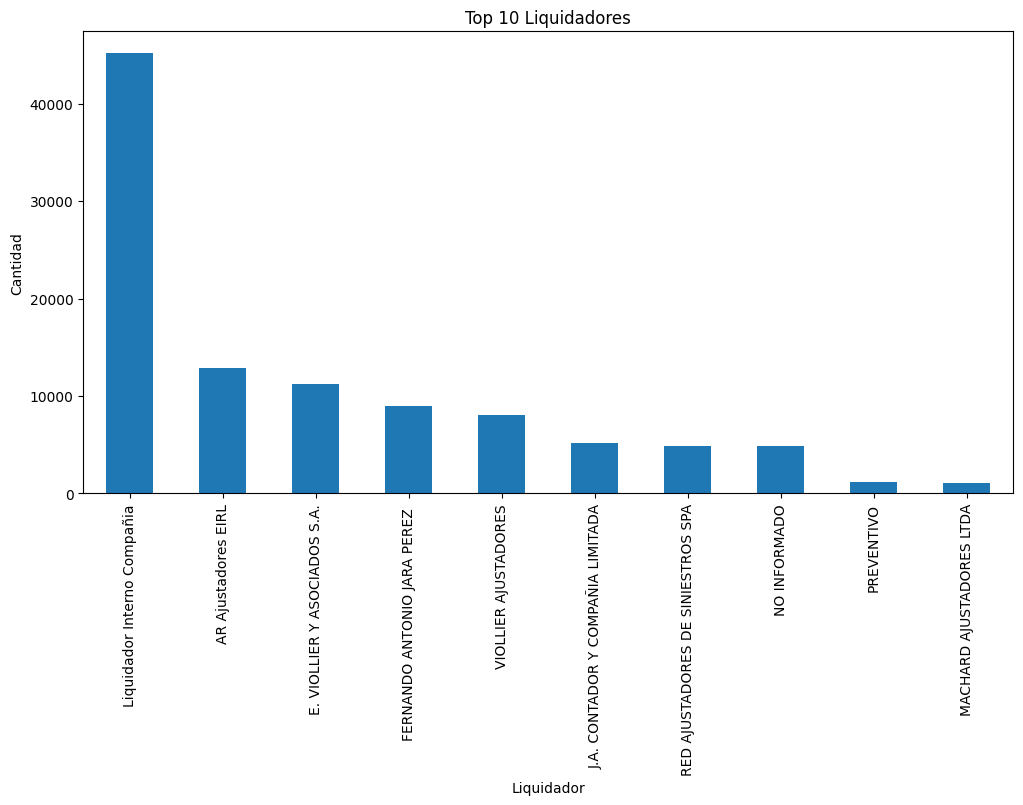

In [ ]:
#TOP 10 Liquidadores
plt.figure(figsize=(12,6))

datos['Liquidador'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Liquidadores')
plt.xlabel('Liquidador')
plt.ylabel('Cantidad')
plt.xticks(rotation=90)
plt.show()

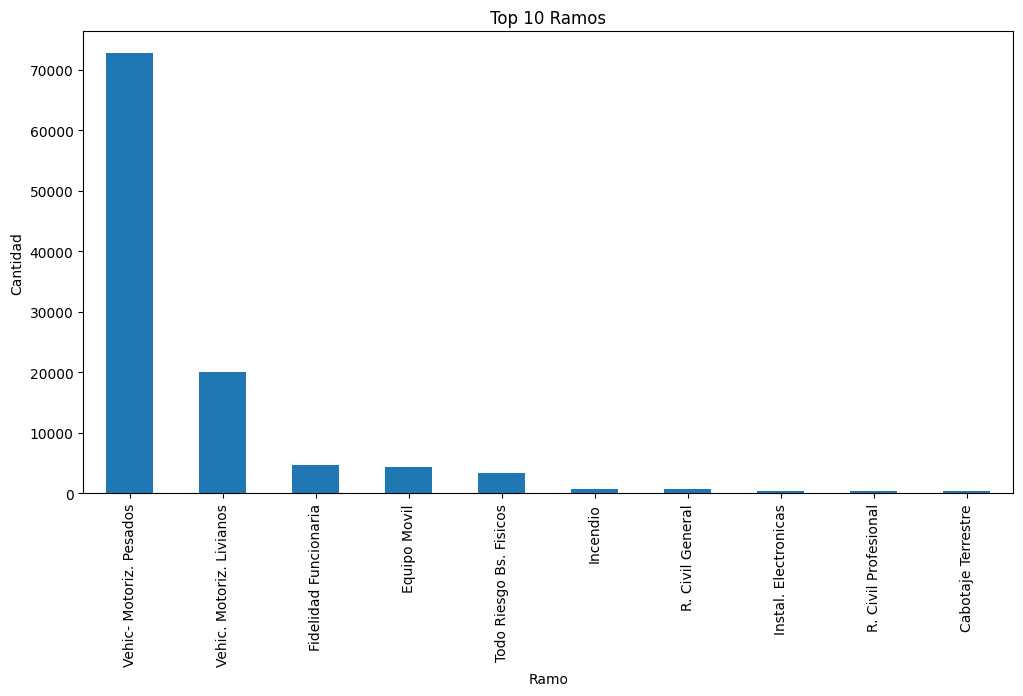

In [ ]:
#TOP 10 Ramos
plt.figure(figsize=(12,6))

datos['Nombre_Ramo'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Ramos')
plt.xlabel('Ramo')
plt.ylabel('Cantidad')
plt.xticks(rotation=90)
plt.show()

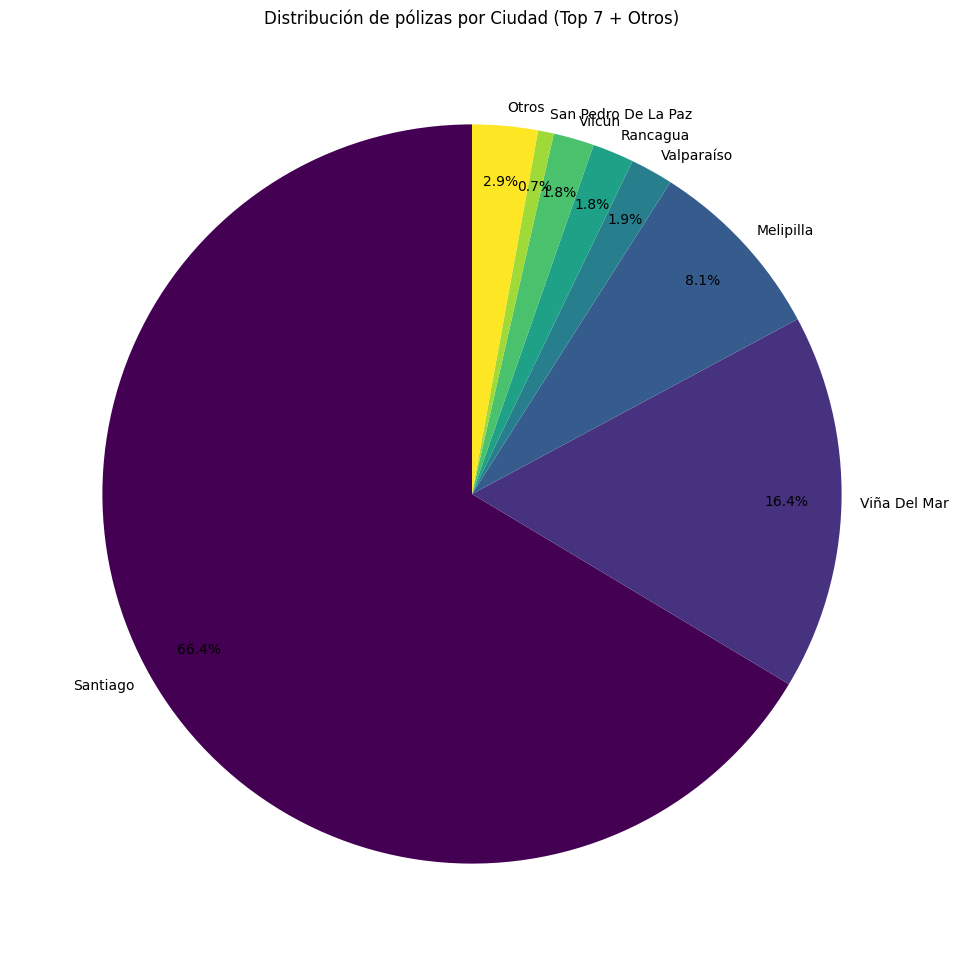

In [ ]:
# Gráfico de torta para Ciudad_y

# Obtener el conteo de cada ciudad
ciudad_counts = datos['Ciudad_y'].value_counts()

# Seleccionar las top 7 ciudades y agrupar el resto como 'Otros'
top_7_ciudades = ciudad_counts.head(7)
otros_ciudades = pd.Series([ciudad_counts.iloc[7:].sum()], index=['Otros'])

# Combinar top 7 y 'Otros'
ciudad_pie_data = pd.concat([top_7_ciudades, otros_ciudades])

plt.figure(figsize=(12, 12)) # Increase figure size for more space
ciudad_pie_data.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis',
                         pctdistance=0.85, labeldistance=1.05, # Adjust distances
                         textprops={'fontsize': 10}) # Reduce font size
plt.title('Distribución de pólizas por Ciudad (Top 7 + Otros)')
plt.ylabel('') # Eliminar la etiqueta 'Cantidad' del eje y
plt.show()

##3.2 Análisis Multivariado

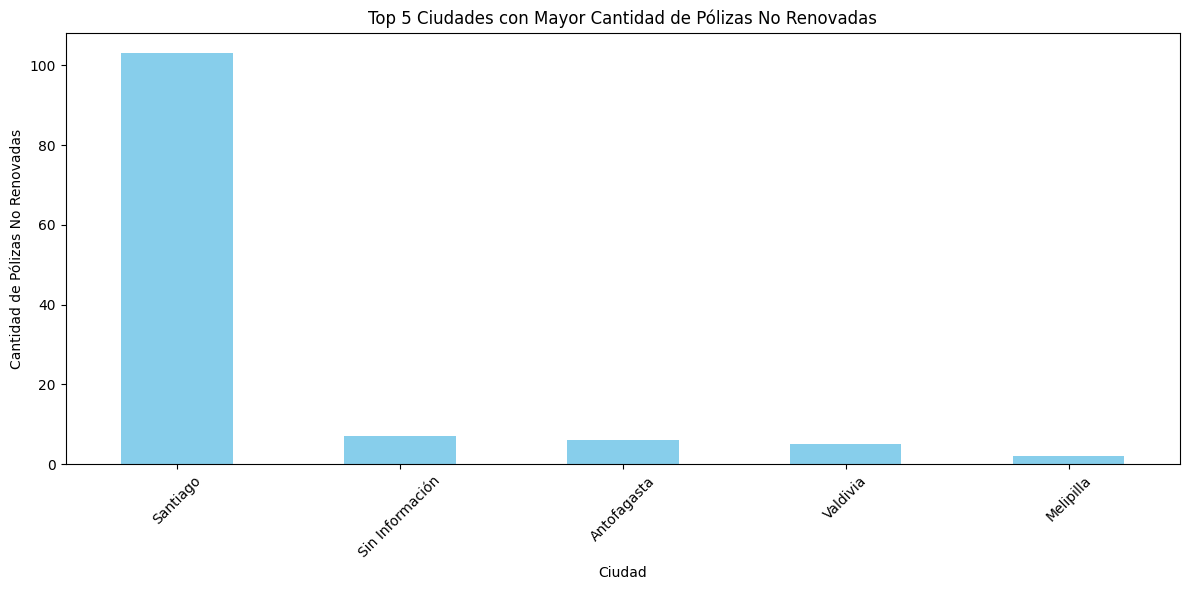

In [ ]:
#Top 5 ciudades con mayor cantidad de Pólizas no Renovadas
# Filtrar el DataFrame para incluir solo las pólizas no renovadas (donde NO_Renovada es 'True' como string)
non_renewed_policies_count = datos[datos['NO_Renovada'] == 'True']

# Contar la cantidad de pólizas no renovadas por ciudad
top_5_ciudades_no_renovadas_count = non_renewed_policies_count['Ciudad_y'].value_counts().head(5)

plt.figure(figsize=(12, 6))
top_5_ciudades_no_renovadas_count.plot(kind='bar', color='skyblue')

plt.title('Top 5 Ciudades con Mayor Cantidad de Pólizas No Renovadas')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Pólizas No Renovadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

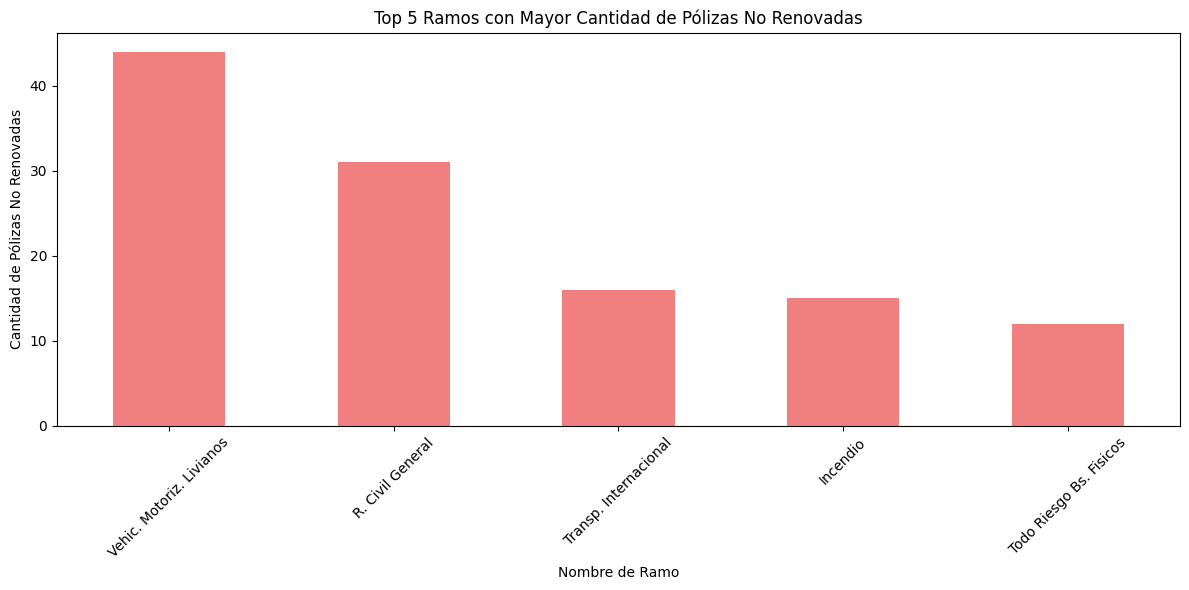

In [ ]:
#Top 5 Ramos con mayor cantidad de Pólizas no Renovadas
# Filtrar el DataFrame para incluir solo las pólizas no renovadas (donde NO_Renovada es 'True' como string)
non_renewed_ramos_count = datos[datos['NO_Renovada'] == 'True']

# Contar la cantidad de pólizas no renovadas por Nombre_Ramo
top_5_ramos_no_renovadas_count = non_renewed_ramos_count['Nombre_Ramo'].value_counts().head(5)

plt.figure(figsize=(12, 6))
top_5_ramos_no_renovadas_count.plot(kind='bar', color='lightcoral')

plt.title('Top 5 Ramos con Mayor Cantidad de Pólizas No Renovadas')
plt.xlabel('Nombre de Ramo')
plt.ylabel('Cantidad de Pólizas No Renovadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

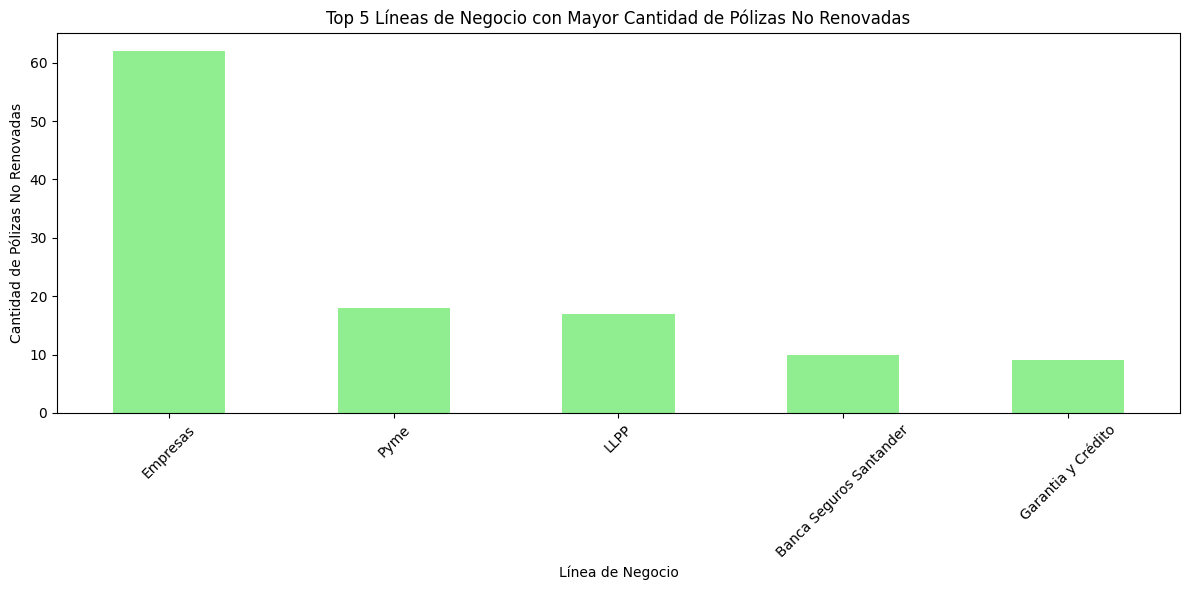

In [ ]:
#Top 5 Líneas de Negocio con mayor cantidad de Pólizas no Renovadas
# Filtrar el DataFrame para incluir solo las pólizas no renovadas (donde NO_Renovada es 'True' como string)
non_renewed_linea_negocio_count = datos[datos['NO_Renovada'] == 'True']

# Contar la cantidad de pólizas no renovadas por Linea_Negocio
top_5_linea_negocio_no_renovadas_count = non_renewed_linea_negocio_count['Linea_Negocio'].value_counts().head(5)

plt.figure(figsize=(12, 6))
top_5_linea_negocio_no_renovadas_count.plot(kind='bar', color='lightgreen')

plt.title('Top 5 Líneas de Negocio con Mayor Cantidad de Pólizas No Renovadas')
plt.xlabel('Línea de Negocio')
plt.ylabel('Cantidad de Pólizas No Renovadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()